In [1]:
import torch                                                          

                                                                      
                                                             
data = torch.load('dataset.pt')

                                                                               
                                                                 
print("Tip objekta:", type(data))

                                                                
                                                   
                                                            
if isinstance(data, dict):
    print("\nKljučevi u dictionary-u:")
    for key in data.keys():
        print(f"  - {key}")

C:\Users\XYZ\AppData\Local\Temp\ipykernel_12728\4133194101.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load('dataset.pt')


Tip objekta: <class 'dict'>

Ključevi u dictionary-u:
  - x_iq
  - x_spec
  - y
  - snr
  - duty_cycle


In [2]:
                                                                        
                                                                   

for key in data.keys():
    value = data[key]

    print(f"Kljuc: '{key}'")
    print(f"Tip: '{type(value)}'")

                                                                            
    if isinstance(value, torch.Tensor):
        print(f"  Shape (oblik): {value.shape}")
        print(f"  Dtype (tip podataka): {value.dtype}")
        print(f"  Min vrednost: {value.min().item()}")
        print(f"  Max vrednost: {value.max().item()}")

    print()                               

Kljuc: 'x_iq'
Tip: '<class 'torch.Tensor'>'
  Shape (oblik): torch.Size([98705, 2, 16384])
  Dtype (tip podataka): torch.float32
  Min vrednost: -109.37040710449219
  Max vrednost: 118.19085693359375

Kljuc: 'x_spec'
Tip: '<class 'torch.Tensor'>'
  Shape (oblik): torch.Size([98705, 2, 128, 128])
  Dtype (tip podataka): torch.float32
  Min vrednost: -10.516491889953613
  Max vrednost: 9.794825553894043

Kljuc: 'y'
Tip: '<class 'torch.Tensor'>'
  Shape (oblik): torch.Size([98705])
  Dtype (tip podataka): torch.int64
  Min vrednost: 0
  Max vrednost: 6

Kljuc: 'snr'
Tip: '<class 'torch.Tensor'>'
  Shape (oblik): torch.Size([98705])
  Dtype (tip podataka): torch.int32
  Min vrednost: -20
  Max vrednost: 30

Kljuc: 'duty_cycle'
Tip: '<class 'torch.Tensor'>'
  Shape (oblik): torch.Size([98705])
  Dtype (tip podataka): torch.float32
  Min vrednost: 0.0
  Max vrednost: 1.0



In [3]:
                                                                          
                                                                    

print("Shape duty_cycle:", data['duty_cycle'].shape)
print("Dtype duty_cycle:", data['duty_cycle'].dtype)

Shape duty_cycle: torch.Size([98705])
Dtype duty_cycle: torch.float32


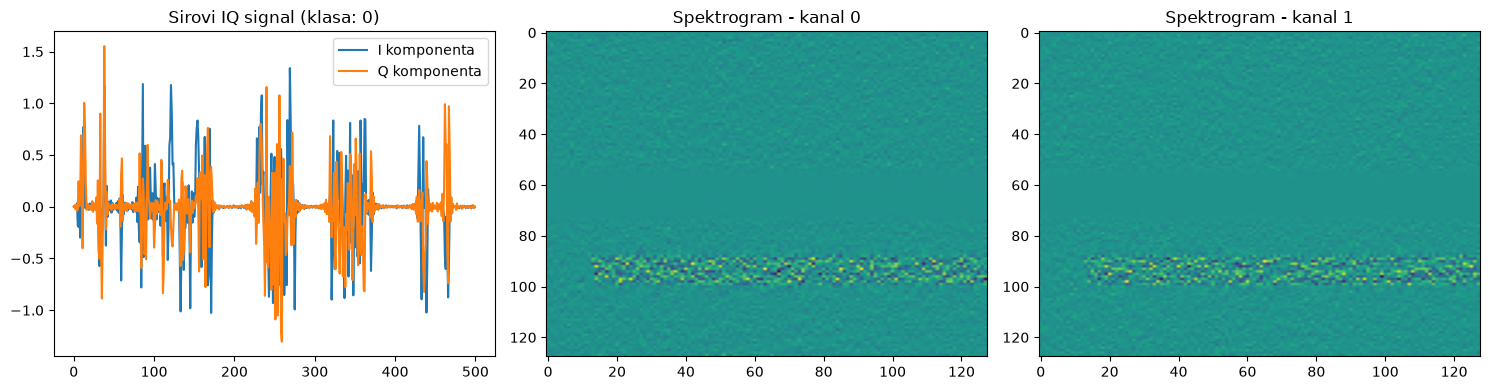

In [4]:
import matplotlib.pyplot as plt  

                                                                      
sample_idx = 0

                                                 
                                                                      
iq_sample = data['x_iq'][sample_idx]

                                                                        
i_component = iq_sample[0]                   
q_component = iq_sample[1]                   

                                                   
                                                                              
spec_sample = data['x_spec'][sample_idx]

                                                
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

                                                                            
axes[0].plot(i_component[:500], label='I komponenta')
axes[0].plot(q_component[:500], label='Q komponenta')
axes[0].set_title(f'Sirovi IQ signal (klasa: {data["y"][sample_idx].item()})')
axes[0].legend()

                                               
axes[1].imshow(spec_sample[0], aspect='auto', cmap='viridis')
axes[1].set_title('Spektrogram - kanal 0')

                                                
axes[2].imshow(spec_sample[1], aspect='auto', cmap='viridis')
axes[2].set_title('Spektrogram - kanal 1')

plt.tight_layout()
plt.show()

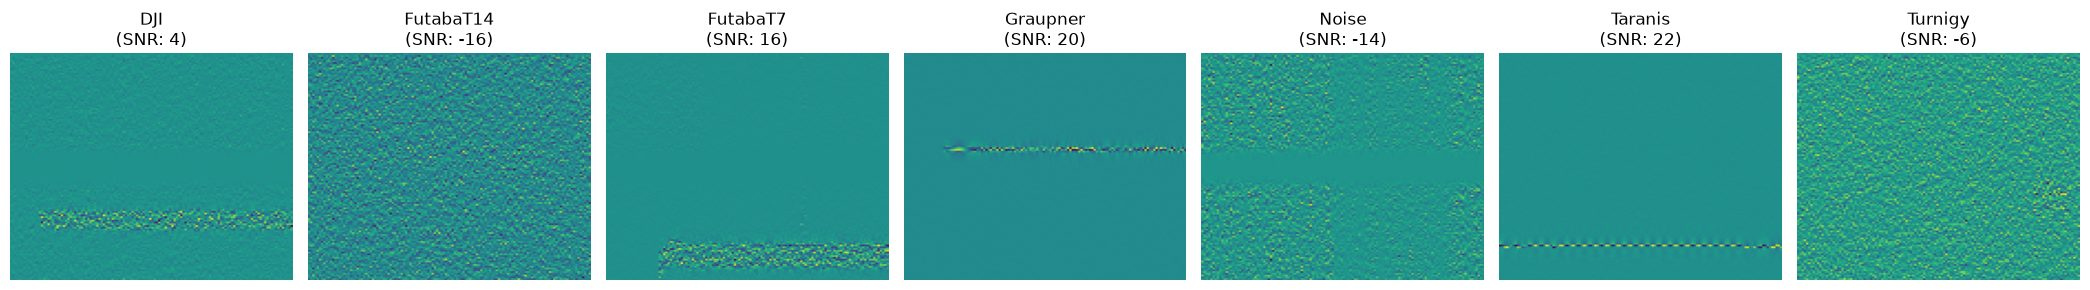

In [5]:
import matplotlib.pyplot as plt

                                                                                          
                                                                                   
class_names = {
    0: 'DJI',
    1: 'FutabaT14',
    2: 'FutabaT7',
    3: 'Graupner',
    4: 'Noise',
    5: 'Taranis',
    6: 'Turnigy'
}

                                                                     
fig, axes = plt.subplots(1, 7, figsize=(21, 3))

                                      
for class_id in range(7):
                                                                                      
                                                                         
    indices_for_class = torch.where(data['y'] == class_id)[0]
    
                                                                                                   
    sample_idx = indices_for_class[0].item()
    
                                                                             
    spec = data['x_spec'][sample_idx][0]
    
                           
    axes[class_id].imshow(spec, aspect='auto', cmap='viridis')
    axes[class_id].set_title(f'{class_names[class_id]}\n(SNR: {data["snr"][sample_idx].item()})')
    axes[class_id].axis('off')                                                

plt.tight_layout()
plt.show()

In [6]:
                          
import numpy as np

                                                          
class_names = {
    0: 'DJI', 1: 'FutabaT14', 2: 'FutabaT7', 3: 'Graupner',
    4: 'Noise', 5: 'Taranis', 6: 'Turnigy'
}

                                                                             
                                                            

print(f"{'Klasa':<12} {'Broj uzoraka':<15} {'Prosečan SNR':<15} {'Min SNR':<10} {'Max SNR':<10}")
print("-" * 65)

for class_id in range(7):
                                                                
    indices_for_class = torch.where(data['y'] == class_id)[0]
    
                                               
    snr_values = data['snr'][indices_for_class]
    
                                                                             
    mean_snr = snr_values.float().mean().item()
    min_snr = snr_values.min().item()
    max_snr = snr_values.max().item()
    count = len(indices_for_class)
    
    print(f"{class_names[class_id]:<12} {count:<15} {mean_snr:<15.2f} {min_snr:<10} {max_snr:<10}")

Klasa        Broj uzoraka    Prosečan SNR    Min SNR    Max SNR   
-----------------------------------------------------------------
DJI          2194            4.76            -20        30        
FutabaT14    6938            5.27            -20        30        
FutabaT7     3661            4.85            -20        30        
Graupner     6481            4.81            -20        30        
Noise        52552           5.00            -20        30        
Taranis      16546           5.05            -20        30        
Turnigy      10333           4.96            -20        30        


In [7]:
from sklearn.model_selection import train_test_split
import numpy as np

                                                                             
                                                                         
                                                                              
                                  

                                                                           
all_indices = np.arange(len(data['y']))

                                                       
labels = data['y'].numpy()                                             

                                                    
                                                                           
                                                                               
                                                                          
train_val_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.15,
    stratify=labels,
    random_state=42
)

                                                      
                                                                     
                                                                              
val_size_relative = 0.15 / 0.85

                                                                             
train_indices, val_indices = train_test_split(
    train_val_indices,
    test_size=val_size_relative,
    stratify=labels[train_val_indices],
    random_state=42
)

                                                                                        
                                                                              
                                                                                       
                                                                                           
                                                                                                 
                                                                                          
                           

                                                                               
print(f"Train:      {len(train_indices)} uzoraka ({len(train_indices)/len(all_indices)*100:.1f}%)")
print(f"Validation: {len(val_indices)} uzoraka ({len(val_indices)/len(all_indices)*100:.1f}%)")
print(f"Test:       {len(test_indices)} uzoraka ({len(test_indices)/len(all_indices)*100:.1f}%)")
print(f"Ukupno:     {len(train_indices) + len(val_indices) + len(test_indices)} uzoraka")

Train:      69093 uzoraka (70.0%)
Validation: 14806 uzoraka (15.0%)
Test:       14806 uzoraka (15.0%)
Ukupno:     98705 uzoraka


In [8]:
import sys
print(sys.executable)
import pandas as pd

                                                                                   
                                                                   

class_names = {
    0: 'DJI', 1: 'FutabaT14', 2: 'FutabaT7', 3: 'Graupner',
    4: 'Noise', 5: 'Taranis', 6: 'Turnigy'
}

                                                                                 
                                            
train_labels = labels[train_indices]
val_labels = labels[val_indices]
test_labels = labels[test_indices]

                                                            
rows = []

for class_id in range(7):
                                                                         
                                                                    
    train_count = np.sum(train_labels == class_id)
    val_count = np.sum(val_labels == class_id)
    test_count = np.sum(test_labels == class_id)
    total = train_count + val_count + test_count
    
    rows.append({
        'Klasa': class_names[class_id],
        'Train': train_count,
        'Train %': f"{train_count/total*100:.1f}%",
        'Val': val_count,
        'Val %': f"{val_count/total*100:.1f}%",
        'Test': test_count,
        'Test %': f"{test_count/total*100:.1f}%"
    })

                                                             
df_check = pd.DataFrame(rows)
print(df_check.to_string(index=False))

c:\Users\XYZ\Desktop\Tehnologije i alati u mašinskom učenju\venv\Scripts\python.exe
    Klasa  Train Train %  Val Val %  Test Test %
      DJI   1536   70.0%  329 15.0%   329  15.0%
FutabaT14   4856   70.0% 1041 15.0%  1041  15.0%
 FutabaT7   2563   70.0%  549 15.0%   549  15.0%
 Graupner   4537   70.0%  972 15.0%   972  15.0%
    Noise  36786   70.0% 7883 15.0%  7883  15.0%
  Taranis  11582   70.0% 2482 15.0%  2482  15.0%
  Turnigy   7233   70.0% 1550 15.0%  1550  15.0%


In [9]:
import numpy as np

                                                                                 
                                                                                         
np.savez(
    'train_val_test_split.npz',
    train_indices=train_indices,
    val_indices=val_indices,
    test_indices=test_indices
)

print("Indeksi sačuvani u 'train_val_test_split.npz'")
print(f"Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")

Indeksi sačuvani u 'train_val_test_split.npz'
Train: 69093, Val: 14806, Test: 14806
